<a href="https://colab.research.google.com/github/nattapongbam/Models-for-Tuberculosis/blob/main/catboost_Bi_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
X_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/X_train_Bi21.csv')#.drop(columns=['Unnamed: 0'])
y_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/y_train_Bi21.csv')#.drop(columns=['Unnamed: 0'])

X_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/X_test_Bi21.csv')#.drop(columns=['Unnamed: 0'])
y_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/y_test_Bi21.csv')#.drop(columns=['Unnamed: 0'])

In [ ]:
X_train_te = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/traget_en/X_train_te21.csv')#.drop(columns=['Unnamed: 0'])
y_train_te = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/traget_en/y_train_te21.csv')#.drop(columns=['Unnamed: 0'])
X_test_te = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/traget_en/X_test_te21-5.csv')#.drop(columns=['Unnamed: 0'])

In [ ]:
X_train.drop(columns='period_treatment', inplace=True)
X_test.drop(columns='period_treatment', inplace=True)

In [ ]:
X_train

,weight,age,gender_0,gender_1,ICD_10_0,ICD_10_1,ICD_10_2,ICD_10_3,ICD_10_4,ICD_10_5,pos_disease_0,pos_disease_1,HIV_0,HIV_1,HIV_2,CKD,COPD,DM,LD
0,52,71,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0
1,38,85,1,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0
2,53,61,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0
3,39,56,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0
4,50,20,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5558,50,53,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0
5559,56,55,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1
5560,52,56,1,0,0,0,0,0,0,1,0,1,0,1,1,0,0,0,0
5561,50,70,1,0,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0


In [ ]:
# X_train.drop(columns='period_treatment', inplace=True)
# X_test.drop(columns='period_treatment', inplace=True)

In [ ]:
# from sklearn.model_selection import train_test_split

# X_train, X_val, y_train, y_val = train_test_split(
#     X_train, y_train,
#     test_size=0.2,
#     # random_seed=42,
#     stratify=y_train
# )

In [ ]:
# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(
#     X_train_, y_train_,
#     test_size=0.2,
#     random_state=42,
#     stratify=y_train_
# )

# print(f"จำนวนข้อมูล Train: {len(X_train)} แถว")
# print(f"จำนวนข้อมูล Test: {len(X_val)} แถว")

In [ ]:
y_train.value_counts()

,count
0,
1,3000
0,2563


In [ ]:
y_train_te.value_counts()

,count
0,
1,3000
0,2563


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
import numpy as np

aggressive_weights = [1, 1.2]

model = CatBoostClassifier(
    # loss_function='Focal:alpha=0.35;gamma=2.0',
    iterations=1000,
    learning_rate=0.01,
    max_depth=8,
    # eval_metric='MacroF1',
    class_weights=aggressive_weights,  #auto_class_weights='Balanced',
    # loss_function='Focal:focal_alpha=0.25;focal_gamma=1.5',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

print("--- Training Step 1: Success vs Risk ---")
model.fit(X_train, y_train)

--- Training Step 1: Success vs Risk ---
0:	total: 61.9ms	remaining: 1m 1s
100:	total: 887ms	remaining: 7.9s
200:	total: 1.82s	remaining: 7.24s
300:	total: 2.56s	remaining: 5.96s
400:	total: 3.22s	remaining: 4.82s
500:	total: 4s	remaining: 3.99s
600:	total: 4.46s	remaining: 2.96s
700:	total: 4.88s	remaining: 2.08s
800:	total: 5.36s	remaining: 1.33s
900:	total: 5.79s	remaining: 636ms
999:	total: 6.28s	remaining: 0us


CatBoostClassifier(class_weights=[1, 1.2], eval_metric='AUC', iterations=1000, learning_rate=0.01, max_depth=8, random_seed=42, verbose=100)

              precision    recall  f1-score   support

       Death     0.4940    0.5204    0.5069       636
     Success     0.8284    0.8128    0.8205      1811

    accuracy                         0.7368      2447
   macro avg     0.6612    0.6666    0.6637      2447
weighted avg     0.7415    0.7368    0.7390      2447



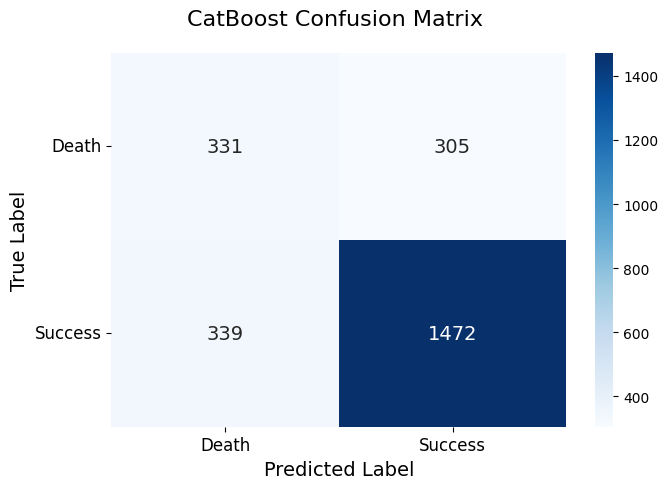

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, f1_score

y_pred = model.predict(X_test)

my_labels = ['Death', 'Success']
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred, target_names=my_labels, digits=4))

plt.figure(figsize=(7, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=my_labels,
                 yticklabels=my_labels,
                 annot_kws={"size": 14}) # ขนาดตัวอักษรของตัวเลขข้างในกล่อง

# 4. ตกแต่งหัวข้อและแกนให้ชัดเจน
plt.title('CatBoost Confusion Matrix ', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)

# 5. ปรับขนาดฟอนต์ของชื่อคลาส (Death, Fail, Success)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

# 6. แสดงผลกราฟ
plt.tight_layout()
plt.show()

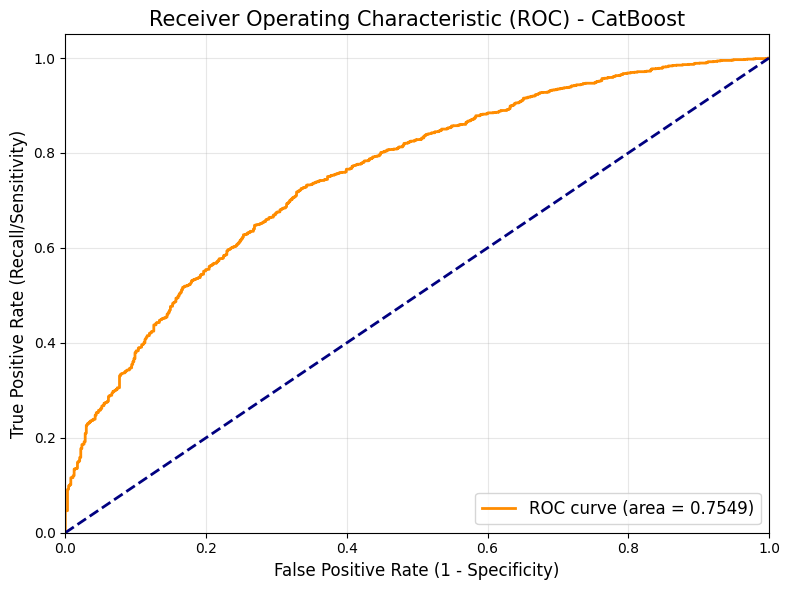

ค่า AUC Score คือ: 0.7549


In [ ]:
from sklearn.metrics import roc_curve, auc

# 1. หาค่าความน่าจะเป็น (Probability) ของคลาส 1 (Success)
# predict_proba จะให้ค่ามา 2 คอลัมน์ [prob_0, prob_1] เราเลือกใช้คอลัมน์ index 1
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. คำนวณค่า False Positive Rate และ True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 3. สร้างกราฟ ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')

# ลากเส้นประตรงกลาง (Random Classifier)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# ตกแต่งกราฟ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall/Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) - CatBoost', fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ค่า AUC Score คือ: {roc_auc:.4f}")

# จบ

In [ ]:
from catboost import CatBoostClassifier
import numpy as np

aggressive_weights = [1, 1.2]

model2 = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    max_depth=5,
    # eval_metric='TotalF1',
    class_weights=aggressive_weights,  #auto_class_weights='Balanced',
    # loss_function='Focal:focal_alpha=0.25;focal_gamma=1.5',
    random_seed=42,
    verbose=100
)

print("--- Training Step 2: Success vs Risk ---")
model2.fit(X_train_te, y_train_te)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, f1_score

y_pred2 = model2.predict(X_test_te)

my_labels = ['Death', 'Success']
cm2 = confusion_matrix(y_test, y_pred2)

print(classification_report(y_test, y_pred2, target_names=my_labels))

plt.figure(figsize=(7, 5))
ax = sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
                 xticklabels=my_labels,
                 yticklabels=my_labels,
                 annot_kws={"size": 14}) # ขนาดตัวอักษรของตัวเลขข้างในกล่อง

# 4. ตกแต่งหัวข้อและแกนให้ชัดเจน
plt.title('CatBoost Confusion Matrix ', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)

# 5. ปรับขนาดฟอนต์ของชื่อคลาส (Death, Fail, Success)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

# 6. แสดงผลกราฟ
plt.tight_layout()
plt.show()

In [ ]:
def hierarchical_predict(X, X_te):
    # 1. ดูความน่าจะเป็นจากโมเดลแรก
    prob1 = model.predict_proba(X)

    is_confident_success = prob1[:, 1] > 0.5

    final_predictions = np.zeros(len(X))

    for i in range(len(X)):
        if is_confident_success[i]:
            final_predictions[i] = 1
        else:
            pred2 = model2.predict(X_te.iloc[[i]])
            final_predictions[i] = pred2[0]

    return final_predictions

In [ ]:
# ทำนายผลในชุด Test
y_final_pred = hierarchical_predict(X_test, X_test_te)

# แสดงผลการวัดผล
from sklearn.metrics import classification_report
print("\n--- Final Hierarchical Classification Report ---")
print(classification_report(y_test, y_final_pred, target_names=['Death', 'Success']))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, f1_score

my_labels = ['Death', 'Success']
cm = confusion_matrix(y_test, y_final_pred)

print(classification_report(y_test, y_final_pred, target_names=my_labels))

plt.figure(figsize=(7, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=my_labels,
                 yticklabels=my_labels,
                 annot_kws={"size": 14}) # ขนาดตัวอักษรของตัวเลขข้างในกล่อง

# 4. ตกแต่งหัวข้อและแกนให้ชัดเจน
plt.title('CatBoost Confusion Matrix ', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)

# 5. ปรับขนาดฟอนต์ของชื่อคลาส (Death, Fail, Success)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

# 6. แสดงผลกราฟ
plt.tight_layout()
plt.show()

In [ ]:
# # ทำนายผลในชุด val
# y_final_pred_check = hierarchical_predict(X_val)

# # แสดงผลการวัดผล
# from sklearn.metrics import classification_report
# print("\n--- Final Hierarchical Classification Report ---")
# print(classification_report(y_val, y_final_pred_check, target_names=['Death', 'Success']))

In [ ]:
y_train.value_counts()

In [ ]:
import pandas as pd
import numpy as np

# สมมติว่า errors_df ของคุณมีคอลัมน์ฟีเจอร์ต้นฉบับอยู่ด้วย
# สร้างคอลัมน์ใหม่เพื่อจัดกลุ่ม
errors_df = X_test.copy()
errors_df['True_Label'] = y_test
errors_df['Predicted_Label'] = y_final_pred
conditions = [
    (errors_df['True_Label'] == 1) & (errors_df['Predicted_Label'] == 1),
    (errors_df['True_Label'] == 0) & (errors_df['Predicted_Label'] == 0),
    (errors_df['True_Label'] == 0) & (errors_df['Predicted_Label'] == 1)
]
choices = ['1_Correct_Success', '2_Correct_Death', '3_Blind_Spots']
errors_df['Analysis_Group'] = np.select(conditions, choices, default='Other')

# ตัดกลุ่ม Other (เช่น ทายผิดเป็น Death) ออกก่อนเพื่อโฟกัสสิ่งที่เราอยากดู
compare_df = errors_df[errors_df['Analysis_Group'] != 'Other']

# เทียบค่าเฉลี่ยของทุกฟีเจอร์ (เลือกเฉพาะคอลัมน์ตัวเลข)
numeric_features = compare_df.select_dtypes(include=[np.number]).columns.drop(['True_Label', 'Predicted_Label'])
profile_summary = compare_df.groupby('Analysis_Group')[numeric_features].mean().T

print("--- เปรียบเทียบหน้าตาของข้อมูล 3 กลุ่ม ---")
print(profile_summary)

# Check overfitt

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, f1_score

y_pred = model.predict(X_val)

my_labels = ['Death', 'Success']
cm2 = confusion_matrix(y_val, y_pred)

print(classification_report(y_val, y_pred, target_names=my_labels))

plt.figure(figsize=(7, 5))
ax = sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
                 xticklabels=my_labels,
                 yticklabels=my_labels,
                 annot_kws={"size": 14}) # ขนาดตัวอักษรของตัวเลขข้างในกล่อง

# 4. ตกแต่งหัวข้อและแกนให้ชัดเจน
plt.title('CatBoost Confusion Matrix ', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)

# 5. ปรับขนาดฟอนต์ของชื่อคลาส (Death, Fail, Success)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

# 6. แสดงผลกราฟ
plt.tight_layout()
plt.show()